## 从 LAS + Wtie 时深表构建时间域低频模型

这个 notebook 读取 `data/vertical_well_las_target_clear` 里的 LAS 文件，提取 MD 域 `Vp` 与 `Rho` 并派生 `AI`；再结合 `output_vertical_well_wtie/tdtable` 中的时深表与解释层位，调用 `lfm_time.py` 生成时间域低频模型，并导出 `npz` 与 `SEG-Y` 文件用于检查。


In [1]:
import json
import re
import sys
from pathlib import Path

import cigsegy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = repo_root.parent
if not (repo_root / "src").exists():
    raise RuntimeError("Could not locate repo root containing 'src'.")

src_root = repo_root / "src"
if str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))

from cup.petrel.load import (
    import_checkshots_petrel,
    import_interpretation_petrel,
    import_well_heads_petrel,
    load_vp_rho_logset_from_las,
)
from cup.seismic.lfm_time import LfmTimeWell, build_lfm_time_model
from cup.seismic.survey import open_survey
from cup.seismic.target_layer import TargetLayer
from wtie.processing import grid


In [2]:
data_root = repo_root / "data"

lfm_output_dir = data_root / "output_lfm_time_from_wtie_20260423"
lfm_output_file = lfm_output_dir / "lfm_time_from_wtie.npz"
lfm_output_segy_file = lfm_output_dir / "lfm_time_from_wtie.segy"

train_config_file = repo_root / "experiments" / "ginn" / "train.yaml"
target_layer_qc_dir = lfm_output_dir / "target_layer_qc"

well_heads_file = data_root / "raw" / "well_heads"
las_dir = data_root / "vertical_well_las_target_clear"
wtie_root = data_root / "output_vertical_well_wtie_20260416"
tdtable_dir = wtie_root / "tdtable"

seismic_file = data_root / "raw" / "mero se 0116_1ms_new_84_coord.Sgy"
segy_iline = 5
segy_xline = 21
segy_istep = 1
segy_xstep = 4

horizon_files = {
    "bve_top": data_root / "interpre_time" / "bve_top_t",
    "bve_bot": data_root / "interpre_time" / "bve_bot_t",
    "itp_bot": data_root / "interpre_time" / "itp_bot_t",
}

for path in [train_config_file, las_dir, tdtable_dir, well_heads_file, seismic_file, *horizon_files.values()]:
    if not path.exists():
        raise FileNotFoundError(path)

with train_config_file.open("r", encoding="utf-8") as file:
    train_config = yaml.safe_load(file)

target_layer_config = {
    "min_thickness": train_config.get("target_layer_min_thickness"),
    "nearest_distance_limit": train_config.get("target_layer_nearest_distance_limit"),
    "outlier_threshold": train_config.get("target_layer_outlier_threshold"),
    "outlier_min_neighbor_count": train_config.get("target_layer_outlier_min_neighbor_count"),
}

las_dir


WindowsPath('c:/Users/WangQinZhuo/Program/libra_workflow_standardize/data/vertical_well_las_target_clear')

In [3]:
STEM_PATTERN = re.compile(r"^(?P<well_name>.+)_(?P<offset>-?\d+(?:\.\d+)?)$")


def parse_artifact_stem(stem: str) -> tuple[str, float]:
    match = STEM_PATTERN.match(stem)
    if match is None:
        raise ValueError(f"Unrecognized artifact stem: {stem}")
    return match.group("well_name"), float(match.group("offset"))


def collect_las_wtie_artifacts(las_dir: Path, tdtable_dir: Path) -> pd.DataFrame:
    las_map = {path.stem: path for path in sorted(las_dir.glob("*.las"))}
    tdt_map = {path.stem: path for path in sorted(tdtable_dir.glob("*.txt"))}

    if not las_map:
        raise ValueError("No LAS files were found.")
    if not tdt_map:
        raise ValueError("No tdtable files were found.")

    records = []
    missing_las = []
    for stem, tdtable_file in tdt_map.items():
        well_name, interpretation_offset = parse_artifact_stem(stem)
        las_file = las_map.get(well_name)
        if las_file is None:
            missing_las.append(stem)
            continue

        records.append(
            {
                "stem": stem,
                "well_name": well_name,
                "interpretation_offset": interpretation_offset,
                "las_file": las_file,
                "tdtable_file": tdtable_file,
            }
        )

    if missing_las:
        print("Stems missing LAS:", missing_las)
    if not records:
        raise ValueError("No paired LAS/tdtable artifacts were found.")

    unused_las = sorted(set(las_map) - {record["well_name"] for record in records})
    if unused_las:
        print("LAS files without paired tdtable:", unused_las)

    return pd.DataFrame.from_records(records).sort_values(["well_name", "interpretation_offset"]).reset_index(drop=True)


def load_ai_log_from_las(las_file: Path) -> grid.Log:
    logset_md = load_vp_rho_logset_from_las(las_file)
    ai_log = logset_md.AI
    if not ai_log.is_md:
        raise ValueError(f"Expected MD-domain AI log from LAS, got basis_type={ai_log.basis_type}.")
    return ai_log


def build_target_layer(geometry: dict) -> TargetLayer:
    raw_horizons = {
        horizon_name: import_interpretation_petrel(horizon_file) for horizon_name, horizon_file in horizon_files.items()
    }

    return TargetLayer(
        raw_horizon_dfs=raw_horizons,
        geometry=geometry,
        horizon_names=list(horizon_files.keys()),
        qc_output_dir=target_layer_qc_dir,
        min_thickness=target_layer_config["min_thickness"],
        nearest_distance_limit=target_layer_config["nearest_distance_limit"],
        outlier_threshold=target_layer_config["outlier_threshold"],
        outlier_min_neighbor_count=target_layer_config["outlier_min_neighbor_count"],
    )


def build_lfm_wells(artifact_df: pd.DataFrame, well_heads_df: pd.DataFrame) -> list[LfmTimeWell]:
    head_lookup = well_heads_df.copy()
    head_lookup["_name_norm"] = head_lookup["Name"].astype(str).str.strip()
    head_lookup = head_lookup.set_index("_name_norm", drop=False)

    wells = []
    for row in artifact_df.itertuples(index=False):
        if row.well_name not in head_lookup.index:
            raise KeyError(f"Well '{row.well_name}' not found in well heads file.")

        head = head_lookup.loc[row.well_name]
        ai_log_md = load_ai_log_from_las(row.las_file)  # type: ignore[arg-type]
        tdtable = import_checkshots_petrel(row.tdtable_file, depth_domain="md")  # type: ignore[arg-type]

        wells.append(
            LfmTimeWell(
                well_name=row.well_name,  # type: ignore[arg-type]
                property_name="AI",
                property_log=ai_log_md,
                time_depth_table=tdtable,
                x=float(head["Surface X"]),
                y=float(head["Surface Y"]),
                metadata={
                    "artifact_stem": row.stem,
                    "las_file": str(row.las_file),  # type: ignore[arg-type]
                    "interpretation_offset": float(row.interpretation_offset),  # type: ignore[arg-type]
                    "kb": float(head["Well datum value"]),
                },
            )
        )

    return wells


In [4]:
artifact_df = collect_las_wtie_artifacts(las_dir=las_dir, tdtable_dir=tdtable_dir)
well_heads_df = import_well_heads_petrel(well_heads_file)

print(f"Found {len(artifact_df)} paired wells.")
artifact_df


Found 7 paired wells.


,stem,well_name,interpretation_offset,las_file,tdtable_file
0,2-ANP-2A-RJS_0.0,2-ANP-2A-RJS,0.000,c:\Users\WangQinZhuo\Program\libra_workflow_st...,c:\Users\WangQinZhuo\Program\libra_workflow_st...
1,L1-NW1_0.03,L1-NW1,0.030,c:\Users\WangQinZhuo\Program\libra_workflow_st...,c:\Users\WangQinZhuo\Program\libra_workflow_st...
2,L3-NW2A_0.012,L3-NW2A,0.012,c:\Users\WangQinZhuo\Program\libra_workflow_st...,c:\Users\WangQinZhuo\Program\libra_workflow_st...
3,L6-NW3A_-0.022,L6-NW3A,-0.022,c:\Users\WangQinZhuo\Program\libra_workflow_st...,c:\Users\WangQinZhuo\Program\libra_workflow_st...
4,L9-NW4A_0.032,L9-NW4A,0.032,c:\Users\WangQinZhuo\Program\libra_workflow_st...,c:\Users\WangQinZhuo\Program\libra_workflow_st...
5,NW11_0.03,NW11,0.030,c:\Users\WangQinZhuo\Program\libra_workflow_st...,c:\Users\WangQinZhuo\Program\libra_workflow_st...
6,NW7_0.036,NW7,0.036,c:\Users\WangQinZhuo\Program\libra_workflow_st...,c:\Users\WangQinZhuo\Program\libra_workflow_st...


In [5]:
survey = open_survey(
    seismic_file,
    seismic_type="segy",
    segy_options={
        "iline": segy_iline,
        "xline": segy_xline,
        "istep": segy_istep,
        "xstep": segy_xstep,
    },
)
geometry = survey.query_geometry(domain="time")
target_layer = build_target_layer(geometry)

print("Horizon names:", target_layer.horizon_names)
print("Zones:", target_layer.iter_zones())
print("TargetLayer QC dir:", target_layer_qc_dir)
display(target_layer.qc_summary_df)
geometry


100%|██████████| 361201/361201 [00:00<00:00, 1449964.59it/s]


Horizon names: ['bve_top', 'bve_bot', 'itp_bot']
Zones: [('bve_top', 'bve_bot'), ('bve_bot', 'itp_bot')]
TargetLayer QC dir: c:\Users\WangQinZhuo\Program\libra_workflow_standardize\data\output_lfm_time_from_wtie_20260423\target_layer_qc


,record_type,horizon_pair,top_name,bottom_name,total_traces,pair_no_support_count,crossing_count,thin_count,pair_valid_count,min_thickness,outlier_enabled,outlier_threshold,outlier_min_neighbor_count,outlier_total_points,outlier_removed_points,outlier_removed_ratio,filled_model_count,filled_by_thickness_interpolation_count,nearest_distance_limit
0,horizon,bve_top,bve_top,,361201,0,0,0,361201,0.001,True,0.02,2.0,361201.0,0.0,0.00000,NaN,NaN,NaN
1,horizon,bve_bot,bve_bot,,361201,0,0,0,361201,0.001,True,0.02,2.0,361201.0,0.0,0.00000,NaN,NaN,NaN
2,horizon,itp_bot,itp_bot,,361201,0,0,0,361201,0.001,True,0.02,2.0,358292.0,86.0,0.00024,NaN,NaN,NaN
3,pair,bve_top->bve_bot,bve_top,bve_bot,361201,0,0,0,361201,0.001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,pair,bve_bot->itp_bot,bve_bot,itp_bot,361201,0,0,0,361201,0.001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,global,__trace_global__,,,361201,0,0,0,361201,0.001,NaN,0.02,2.0,NaN,NaN,NaN,361201.0,0.0,NaN


{'n_il': 601,
 'inline_min': 1501.0,
 'inline_max': 2101.0,
 'inline_step': 1.0,
 'n_xl': 601,
 'xline_min': 4199.0,
 'xline_max': 6599.0,
 'xline_step': 4.0,
 'n_sample': 1201,
 'sample_min': 4.8,
 'sample_max': 6.0,
 'sample_step': 0.001000000000000334,
 'sample_domain': 'time',
 'sample_unit': 's'}

In [6]:
lfm_wells = build_lfm_wells(artifact_df, well_heads_df)

well_summary = pd.DataFrame(
    [
        {
            "well_name": well.well_name,
            "x": well.x,
            "y": well.y,
            "basis_type": well.property_log.basis_type,
            "ai_samples": int(well.property_log.size),
            "basis_min": float(well.property_log.basis.min()),
            "basis_max": float(well.property_log.basis.max()),
            "tdt_samples": int(well.time_depth_table.size),
            "interpretation_offset": well.metadata.get("interpretation_offset"),  # type: ignore[arg-type]
        }
        for well in lfm_wells
    ]
)
well_summary


,well_name,x,y,basis_type,ai_samples,basis_min,basis_max,tdt_samples,interpretation_offset
0,2-ANP-2A-RJS,779526.88,7278710.51,MD (kb) [m],40460,2000.000,6049.792,5775,0.000
1,L1-NW1,782033.00,7275558.00,MD (kb) [m],5812,5159.959,5741.626,3907,0.030
2,L3-NW2A,776850.00,7268698.00,MD (kb) [m],6514,5223.000,5874.936,5560,0.012
3,L6-NW3A,778537.00,7273461.00,MD (kb) [m],6119,5268.163,5880.561,5117,-0.022
4,L9-NW4A,781898.00,7278121.00,MD (kb) [m],5265,5357.000,5883.914,5264,0.032
5,NW11,778190.00,7276407.00,MD (kb) [m],4895,5483.200,5973.078,4556,0.030
6,NW7,779813.00,7270613.00,MD (kb) [m],4187,5219.957,5638.966,3042,0.036


In [7]:
lfm_result = build_lfm_time_model(
    target_layer=target_layer,
    wells=lfm_wells,
    survey=survey,
    boundary_extension_samples=50,
    n_slices=20,
    variogram="spherical",
    exact=True,
    nugget=0.0,
)

print("volume shape:", lfm_result.volume.shape)
print("variance shape:", lfm_result.variance_volume.shape)
print("property:", lfm_result.metadata["property_name"])
print("zones:", lfm_result.metadata["zone_names"])
print("wells:", lfm_result.metadata["well_names"])


c:\Users\WangQinZhuo\Program\libra_workflow_standardize\src\wtie\processing\grid.py:1888: UserWarning: Clipping log start to match the time-depth table (MD) minimum depth.
  warnings.warn("Clipping log start to match the time-depth table (MD) minimum depth.")
c:\Users\WangQinZhuo\Program\libra_workflow_standardize\src\wtie\processing\grid.py:1890: UserWarning: Truncating log as the time-depth table (MD) does not reach the maximum depth.
  warnings.warn("Truncating log as the time-depth table (MD) does not reach the maximum depth.")


volume shape: (601, 601, 1201)
variance shape: (601, 601, 1201)
property: AI
zones: [['top_extension', 'bve_top'], ['bve_top', 'bve_bot'], ['bve_bot', 'itp_bot'], ['itp_bot', 'bottom_extension']]
wells: ['2-ANP-2A-RJS', 'L1-NW1', 'L3-NW2A', 'L6-NW3A', 'L9-NW4A', 'NW11', 'NW7']


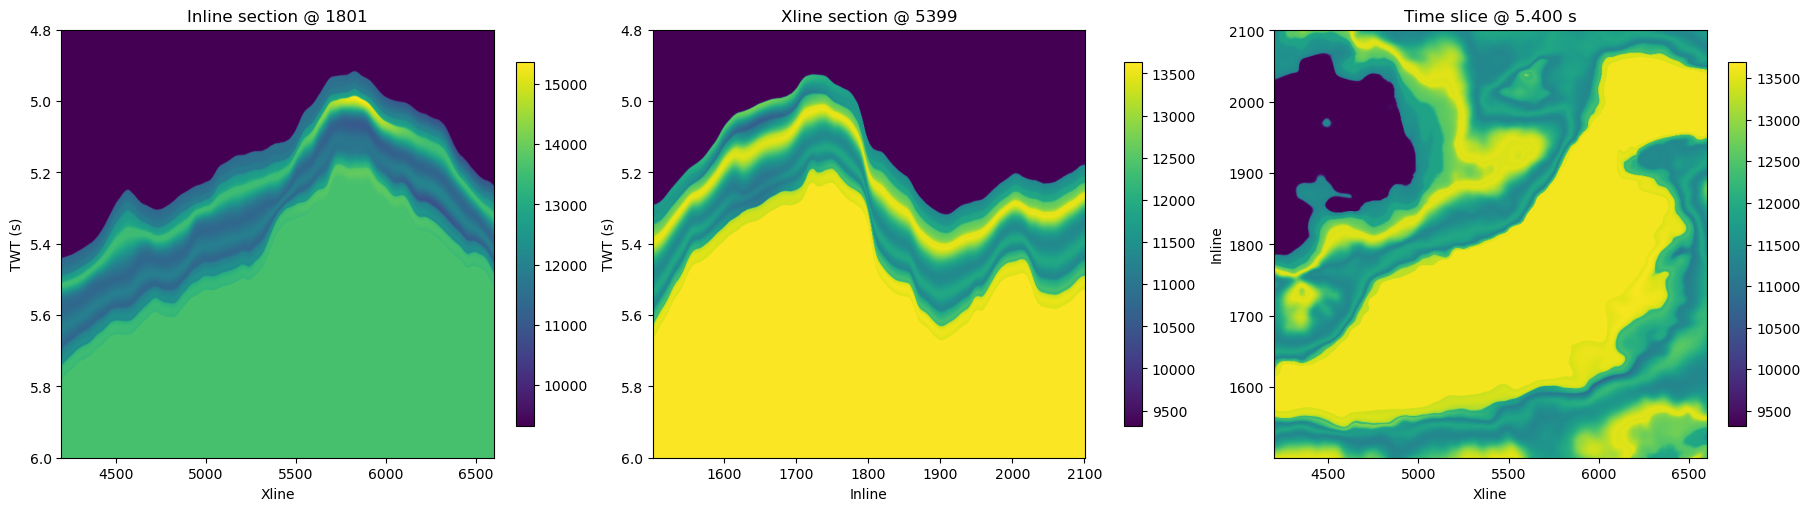

In [8]:
ilines = lfm_result.ilines
xlines = lfm_result.xlines
samples = lfm_result.samples
volume = lfm_result.volume

i_il = len(ilines) // 2
i_xl = len(xlines) // 2
i_t = len(samples) // 2

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

im0 = axes[0].imshow(
    volume[i_il, :, :].T,
    aspect="auto",
    origin="upper",
    extent=[xlines[0], xlines[-1], samples[-1], samples[0]],
    cmap="viridis",
)
axes[0].set_title(f"Inline section @ {ilines[i_il]:.0f}")
axes[0].set_xlabel("Xline")
axes[0].set_ylabel("TWT (s)")
fig.colorbar(im0, ax=axes[0], shrink=0.85)

im1 = axes[1].imshow(
    volume[:, i_xl, :].T,
    aspect="auto",
    origin="upper",
    extent=[ilines[0], ilines[-1], samples[-1], samples[0]],
    cmap="viridis",
)
axes[1].set_title(f"Xline section @ {xlines[i_xl]:.0f}")
axes[1].set_xlabel("Inline")
axes[1].set_ylabel("TWT (s)")
fig.colorbar(im1, ax=axes[1], shrink=0.85)

im2 = axes[2].imshow(
    volume[:, :, i_t],
    aspect="auto",
    origin="lower",
    extent=[xlines[0], xlines[-1], ilines[0], ilines[-1]],
    cmap="viridis",
)
axes[2].set_title(f"Time slice @ {samples[i_t]:.3f} s")
axes[2].set_xlabel("Xline")
axes[2].set_ylabel("Inline")
fig.colorbar(im2, ax=axes[2], shrink=0.85)

plt.show()


In [9]:
coverage_rows = []
for zone_name, zone_stats in lfm_result.coverage_stats["zones"].items():
    coverage_rows.append(
        {
            "zone": zone_name,
            "n_slices": len(zone_stats["slice_control_counts"]),
            "min_controls": int(np.min(zone_stats["slice_control_counts"])),
            "max_controls": int(np.max(zone_stats["slice_control_counts"])),
            "mean_controls": float(np.mean(zone_stats["slice_control_counts"])),
        }
    )

pd.DataFrame(coverage_rows)


,zone,n_slices,min_controls,max_controls,mean_controls
0,top_extension->bve_top,20,1,3,2.10
1,bve_top->bve_bot,20,3,7,5.80
2,bve_bot->itp_bot,20,3,7,6.15
3,itp_bot->bottom_extension,20,1,3,1.95


In [10]:
lfm_output_dir.mkdir(parents=True, exist_ok=True)

np.savez_compressed(
    lfm_output_file,
    volume=lfm_result.volume.astype(np.float32),
    variance_volume=lfm_result.variance_volume.astype(np.float32),
    ilines=lfm_result.ilines,
    xlines=lfm_result.xlines,
    samples=lfm_result.samples,
    geometry_json=json.dumps(lfm_result.geometry, ensure_ascii=False),
    metadata_json=json.dumps(lfm_result.metadata, ensure_ascii=False),
    coverage_stats_json=json.dumps(lfm_result.coverage_stats, ensure_ascii=False),
)

lfm_volume_export = np.ascontiguousarray(lfm_result.volume.astype(np.float32))
keylocs = [segy_iline, segy_xline, segy_istep, segy_xstep]


def build_textual_header(title: str, lines: list[str]) -> str:
    rows = [f"C{idx:>2d} {text}"[:80].ljust(80) for idx, text in enumerate([title, *lines], start=1)]
    rows.extend([f"C{idx:>2d}".ljust(80) for idx in range(len(rows) + 1, 41)])
    textual = "".join(rows)
    if len(textual) != 3200:
        raise ValueError(f"Expected 3200-char textual header, got {len(textual)}")
    return textual


lfm_textual = build_textual_header(
    "WTIE low-frequency model volume (LAS AI)",
    [
        f"artifact={lfm_output_file.name}",
        f"n_wells={len(lfm_wells)}",
        "source=vertical_well_las_target_clear",
        "n_slices=20 variogram=spherical",
        "exact=True nugget=0.0",
    ],
)

cigsegy.create_by_sharing_header(
    str(lfm_output_segy_file),
    str(seismic_file),
    lfm_volume_export,
    keylocs=keylocs,
    textual=lfm_textual,
)

print(f"Saved LFM artifact to: {lfm_output_file}")
print(f"Exported LFM SEG-Y to: {lfm_output_segy_file}")
lfm_output_segy_file


Saved LFM artifact to: c:\Users\WangQinZhuo\Program\libra_workflow_standardize\data\output_lfm_time_from_wtie_20260423\lfm_time_from_wtie.npz
Exported LFM SEG-Y to: c:\Users\WangQinZhuo\Program\libra_workflow_standardize\data\output_lfm_time_from_wtie_20260423\lfm_time_from_wtie.segy


WindowsPath('c:/Users/WangQinZhuo/Program/libra_workflow_standardize/data/output_lfm_time_from_wtie_20260423/lfm_time_from_wtie.segy')